# Model 02: PyTorch LSTM with Attention

Deep learning model with:
- Bidirectional LSTM layers
- Multi-head self-attention mechanism
- Dropout regularization
- Early stopping

In [1]:
pip install torch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
sys.path.insert(0, '..')

from src.models.lstm_model import LSTMForecaster
from src.evaluation.metrics import MetricsCalculator, train_test_split_by_date
from src.features.builders import FeatureBuilder

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
df = pd.read_csv('../data/processed/features_full.csv', parse_dates=['date'])

builder = FeatureBuilder()
feature_cols = builder.get_feature_columns(df, target_col='new_cases')
df_clean = df.dropna(subset=feature_cols + ['new_cases'])
train_df, val_df, test_df = train_test_split_by_date(df_clean, test_size=0.15, val_size=0.1)

X_train = train_df[feature_cols].values
y_train = train_df['new_cases'].values
X_val = val_df[feature_cols].values
y_val = val_df['new_cases'].values
X_test = test_df[feature_cols].values
y_test = test_df['new_cases'].values

print(f"\nData shapes:")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

PyTorch version: 2.11.0+cpu
CUDA available: False

Data shapes:
Train: (873, 48), Val: (98, 48), Test: (172, 48)


## Train LSTM Model

In [ ]:
lstm_model = LSTMForecaster(
    sequence_length=14,
    hidden_size=128,
    num_layers=2,
    num_heads=4,
    dropout=0.2,
    learning_rate=0.001,
    batch_size=32,
    epochs=100,
    patience=15
)

print("\nTraining LSTM model...")
lstm_model.fit(
    X_train, y_train,
    X_val, y_val,
    feature_names=feature_cols
)

print("\nTraining Done!")


Training LSTM model...

Training complete!


## Evaluate on Test Set

Test Set Performance:

Metrics:
----------------------------------------
  MAE     : 13375.6159
  RMSE    : 13405.1125
  MAPE    : 6536.8776
  MDA     : 53.1646
  R2      : -226.4792


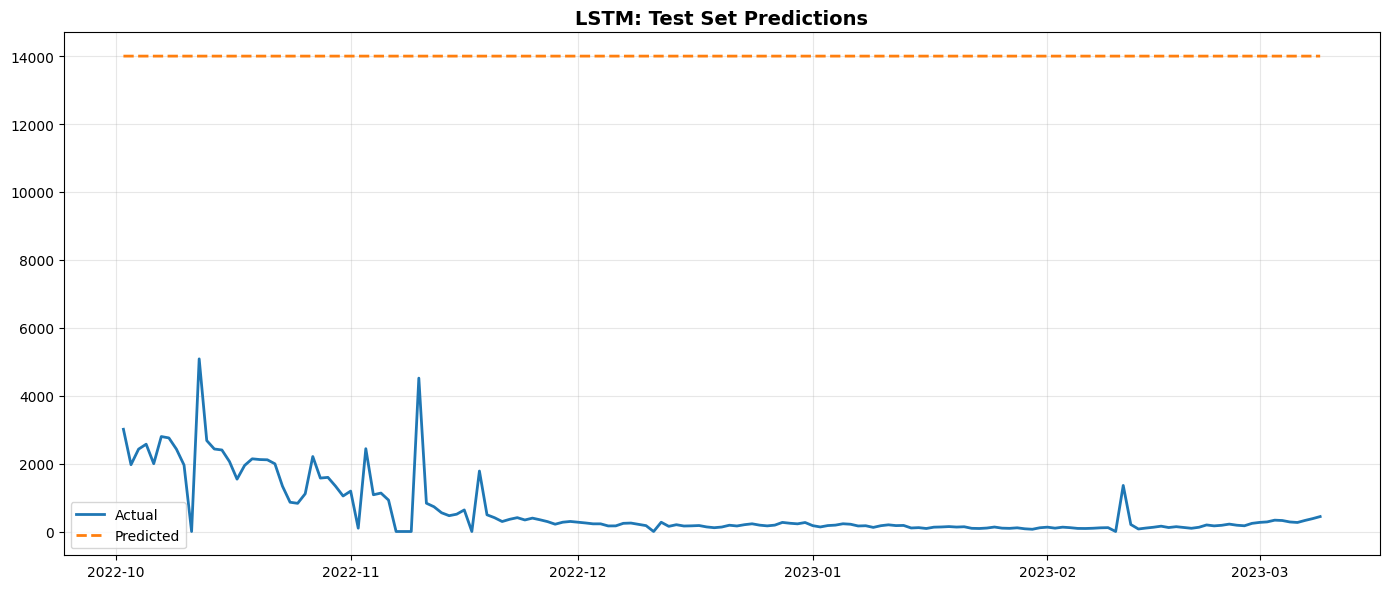

In [ ]:
y_pred = lstm_model.predict(X_test)
y_test_adjusted = y_test[lstm_model.sequence_length-1:lstm_model.sequence_length-1+len(y_pred)]

print("Test set performance:")
metrics = MetricsCalculator.print_metrics(y_test_adjusted, y_pred)

fig, ax = plt.subplots(figsize=(14, 6))
dates = test_df['date'].values[lstm_model.sequence_length-1:lstm_model.sequence_length-1+len(y_pred)]
ax.plot(dates, y_test_adjusted, label='Actual', linewidth=2)
ax.plot(dates, y_pred, label='Predicted', linewidth=2, linestyle='--')
ax.set_title('LSTM: Test Set Predictions', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/05_lstm_predictions.png', dpi=300)
plt.show()

In [ ]:
# Save model
import os
os.makedirs('../models', exist_ok=True)
lstm_model.save('../models/lstm_model.pt')


✓ Model saved to models/lstm_model.pt
